Number of intersections:  72026
Number of road segments: 227550


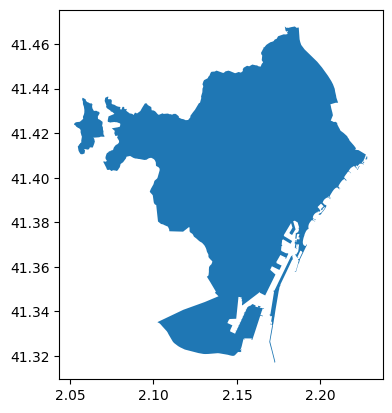

In [2]:
# Importing osmnx
import osmnx as ox  

# Define the polygon for the 1st district of Budapest
admin_district = ox.geocode_to_gdf('Barcelona, Spain')
admin_district.plot()
admin_poly = admin_district.geometry.values[0]

# Load the graph from OSMnx
G = ox.graph_from_polygon(admin_poly, network_type='walk')

print('Number of intersections: ', G.number_of_nodes())
print('Number of road segments:',  G.number_of_edges())

In [28]:
import osmnx as ox
import networkx as nx
import geopandas as gpd
import pandas as pd
from shapely.geometry import Point


walking_speed = 1.39

for u, v, data in G.edges(data=True):
    data["travel_time"] = data["length"] / walking_speed

points = [
    {"name": "Point A", "lon": 2.11846, "lat": 41.38592},
    {"name": "Point B", "lon": 2.1216, "lat": 41.38672},


]
isochrone_times = [5]

isochrone_polys = []

for p in points:
    center_node = ox.distance.nearest_nodes(G, X=p["lon"], Y=p["lat"])

    for time in isochrone_times:
        subgraph = nx.ego_graph(
            G,
            center_node,
            radius=time * 60,
            distance="travel_time"
        )

        node_points = [
            Point((data["x"], data["y"]))
            for node, data in subgraph.nodes(data=True)
        ]

        polygon = gpd.GeoSeries(node_points).union_all().convex_hull
        isochrone_polys.append(
            gpd.GeoDataFrame(
                {"name": [p["name"]], "time": [time], "geometry": [polygon]},
                crs="EPSG:4326"
            )
        )

isochrone_polys = gpd.GeoDataFrame(pd.concat(isochrone_polys, ignore_index=True), crs="EPSG:4326")

In [31]:
isochrone_polys

,name,time,geometry
0,Point A,5,"POLYGON ((2.1193 41.38254, 2.11711 41.3833, 2...."
1,Point B,5,"POLYGON ((2.12224 41.38363, 2.11809 41.3852, 2..."


In [33]:
import altair as alt

alt.Chart(isochrone_polys).mark_geoshape(
    fill='lightblue',
    stroke='black',
    strokeWidth=1
).encode(
    tooltip=['name', 'time']
    ,color=alt.Color('name:N', scale=alt.Scale(scheme='blues'), legend=alt.Legend(title='Isochrone Time (minutes)'))
)

alt.Chart(...)

In [34]:
# calculate routing between two points
point_a = (41.38592, 2.11846)  # Point A
point_b = (41.38672, 2.1216)    # Point B

graph = ox.graph_from_polygon(admin_poly, network_type='walk')
route = ox.shortest_path(graph, point_a, point_b, weight='travel_time')
route

/Users/bmantepe/Library/Python/3.12/lib/python/site-packages/osmnx/_validate.py:49: UserWarning: The attribute 'travel_time' is missing or null on some edges.
  _report_validation(is_valid, valid_msg, warn_msg, err_msg)


NodeNotFound: Source 41.38592 is not in G

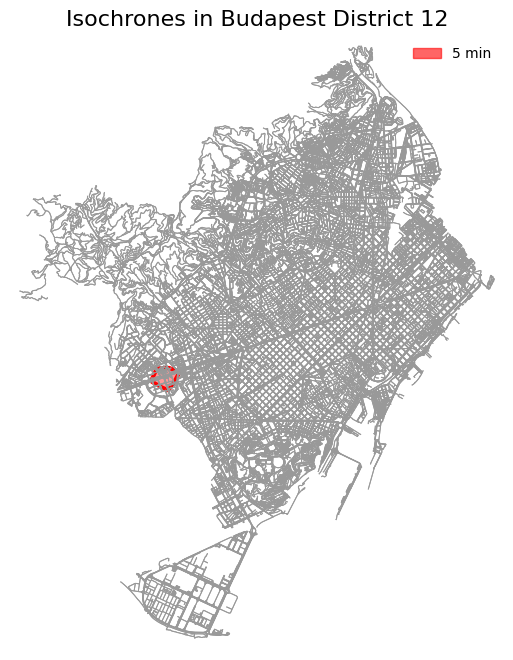

In [22]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Create visuals
fig, ax = plt.subplots(figsize=(8, 8))

# Define the colors of the isochrones
colors = ['red', 'orange', 'yellow', 'green']

# Plot the isochrones
for idx, (polygon, time) in enumerate(reversed(list(zip(isochrone_polys, isochrone_times)))):
    polygon.plot(ax=ax, color=colors[idx], alpha=0.4, label=f'{time} min')
    polygon.plot(ax=ax, color = 'none', edgecolor = colors[idx], linewidth = 3)

# Manually create legend handles
handles = [
    mpatches.Patch(color=colors[idx], alpha=0.6, label=f'{time} min')
    for idx, time in enumerate(reversed(isochrone_times))
]

# Plot the network
ox.plot_graph(G, ax=ax, node_size=0, edge_linewidth=0.7, show=False)

# Add the legend to the plot and set the title
ax.set_title('Isochrones in Budapest District 12', fontsize=16)
legend = plt.legend(handles=handles)
legend.get_frame().set_linewidth(0)  # Remove the legend box's frame

# Show the plot
plt.show()